            EMPIRICAL INPUT MODELING REPORT (MLE)
Total Raw Data Samples Collected : 100
------------------------------------------------------------
FITTED THEORETICAL DISTRIBUTION : NORMAL DISTRIBUTION
 -> Estimated Mean (mu) via MLE  : 4.3754 minutes
 -> Estimated Std Dev (sigma)    : 1.0843 minutes


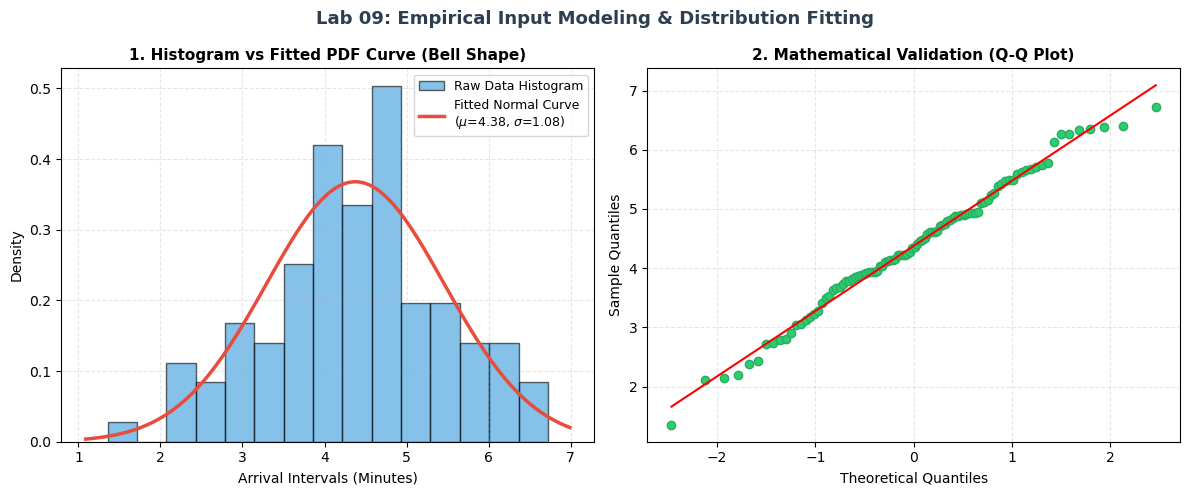

In [6]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# --- ১. বাস্তবসম্মত কল সেন্টার ডেটা তৈরি (Raw Dataset) ---
np.random.seed(42)
# ধরা যাক একটি কল সেন্টারে কাস্টমার আসার মধ্যবর্তী গড় সময় ৪.৫ মিনিট
raw_data = np.random.normal(loc=4.5, scale=1.2, size=100) 

# --- ২. MLE ব্যবহার করে প্যারামিটার ফিট করা ---
mu_mle, sigma_mle = stats.norm.fit(raw_data)

# --- ৩. টেক্সট রিপোর্ট প্রিন্ট ---
print("=" * 60)
print("            EMPIRICAL INPUT MODELING REPORT (MLE)")
print("=" * 60)
print(f"Total Raw Data Samples Collected : {len(raw_data)}")
print("-" * 60)
print("FITTED THEORETICAL DISTRIBUTION : NORMAL DISTRIBUTION")
print(f" -> Estimated Mean (mu) via MLE  : {mu_mle:.4f} minutes")
print(f" -> Estimated Std Dev (sigma)    : {sigma_mle:.4f} minutes")
print("=" * 60)

# --- ৪. গ্রাফিক্যাল ডিসপ্লে (পাশাপাশি দুটি গ্রাফ - ডাবল গ্রাফ ফরম্যাট) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# (ক) প্রথম গ্রাফ: হিস্টোগ্রাম এবং ফিটেড কার্ভ (Density Comparison)
count, bins, ignored = ax1.hist(raw_data, bins=15, density=True, alpha=0.6, color='#3498db', edgecolor='black', label='Raw Data Histogram')
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu_mle, sigma_mle)
ax1.plot(x, p, color='#e74c3c', linewidth=2.5, label=f'Fitted Normal Curve\n($\mu$={mu_mle:.2f}, $\sigma$={sigma_mle:.2f})')

ax1.set_title("1. Histogram vs Fitted PDF Curve (Bell Shape)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Arrival Intervals (Minutes)")
ax1.set_ylabel("Density")
ax1.legend(fontsize=9)
ax1.grid(True, linestyle="--", alpha=0.3)

# (খ) দ্বিতীয় গ্রাফ: গাণিতিক ভ্যালিডেশন (Q-Q Plot)
stats.probplot(raw_data, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('#2ecc71') # বিন্দুর রঙ সবুজ করা হলো
ax2.get_lines()[0].set_markeredgecolor('#27ae60')
ax2.set_title("2. Mathematical Validation (Q-Q Plot)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Sample Quantiles")
ax2.grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Lab 09: Empirical Input Modeling & Distribution Fitting", fontsize=13, fontweight='bold', color='#2c3e50', y=0.98)
plt.tight_layout()
plt.show()